# Velocity and acceleration

Prepared for Shivam Singh · MathTech

## Theory
Differentiate positions using measured dt. The displayed acceleration is the magnitude of the vector derivative of velocity. Missing intervals start new derivative segments.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.analysis.movement import MovementAnalyzer
analyzer = MovementAnalyzer(replace(settings, smoothing_factor=1.0))
times = np.cumsum(np.random.default_rng(7).uniform(.02, .06, 100))
for i, t in enumerate(times):
    analyzer.update(Box(30*t*t, 10*t, 50, 60), float(t), i, 1)
rows = analyzer.rows()


## Visualization

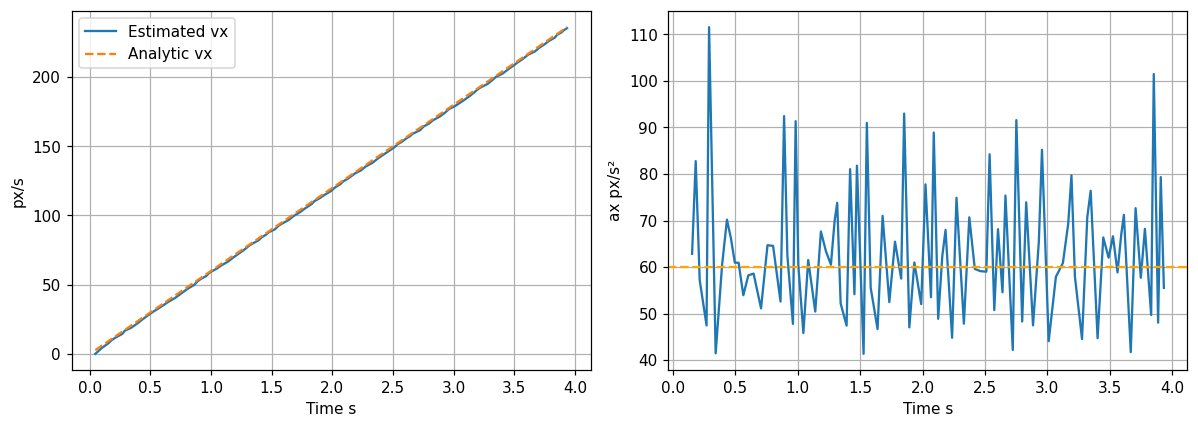

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(times, [r["vx"] for r in rows], label="Estimated vx")
axes[0].plot(times, 60*times, "--", label="Analytic vx")
axes[0].set(xlabel="Time s", ylabel="px/s"); axes[0].legend()
axes[1].plot(times[2:], [r["ax"] for r in rows][2:])
axes[1].axhline(60, ls="--", color="orange"); axes[1].set(xlabel="Time s", ylabel="ax px/s²")
plt.tight_layout(); plt.show()


## Experiment

In [4]:
distance_before = analyzer.total_distance
analyzer.gap()
resumed = analyzer.update(Box(1000, 1000, 50, 60), float(times[-1]+1), 101, 1)
assert resumed.vx == 0 and resumed.vy == 0
assert resumed.total_distance == distance_before
print("Missing-motion interval excluded; segment", resumed.segment)


Missing-motion interval excluded; segment 1


## Observations
Finite differences approximate derivatives over an interval, so they need not equal instantaneous analytic values. Smoothing reduces noise with lag and changes observed path length.

## Conclusion
Report dt, smoothing, coordinate units and missing-data policy with motion results.